# 10 · Sparse, noisy, high-cost scientific data

Product ML usually has millions of cheap, i.i.d. labels. Experimental science has the opposite:
hundreds of labels, each costing days and money, measured with **noise that varies across the
design space**, sometimes **missing** (failed experiments), collected in **batches** that share
hidden conditions (reagent lot, instrument calibration, operator, day). This notebook shows how
each property changes what a model can learn and how we must evaluate it.

| Section | Property | Take-away |
|---|---|---|
| 1 | measurement noise, replicates | noise can be *measured*; it sets an error floor no model can beat |
| 2 | heteroscedasticity | a single σ is wrong everywhere; intervals must depend on $x$ |
| 3 | aleatoric vs epistemic; small-N regime | only epistemic uncertainty shrinks with data; learning curves flatten at the noise floor |
| 4 | missing data | failures that depend on the outcome bias the model |
| 5 | batch effects | random splits leak experimental conditions → optimistic metrics |

## Conceptual model

A measurement is $y = f(x) + b_{r} + \varepsilon$, with $\varepsilon \sim \mathcal N(0, s(x)^2)$
(heteroscedastic noise) and $b_r$ an offset shared by all measurements of batch/round $r$
(a batch effect; zero in the platform's oracle, simulated in §6).

A probabilistic model trained on data $\mathcal D$ predicts $y$ with total variance given by the
**law of total variance** over the model's uncertainty about $f$:

$$\operatorname{Var}[y \mid x, \mathcal D]
  = \underbrace{\mathbb E_{\theta\mid\mathcal D}\big[s_\theta(x)^2\big]}_{\text{aleatoric: irreducible noise}}
  + \underbrace{\operatorname{Var}_{\theta\mid\mathcal D}\big[f_\theta(x)\big]}_{\text{epistemic: shrinks with data}}$$

MC dropout approximates the second term by the spread of $f_\theta(x)$ across dropout masks
(`models.uncertainty.mc_dropout_predict`); `Predictor.predict_with_uncertainty(include_aleatoric=True)`
adds a (homoscedastic) estimate of the first. The expected squared error of *any* predictor
$\hat f$ on a fresh measurement decomposes the same way:

$$\mathbb E\big[(y - \hat f(x))^2\big] = \underbrace{(f(x) - \hat f(x))^2}_{\text{model error}} + s(x)^2,$$

so RMSE against noisy measurements can never go below $\sqrt{\mathbb E[s(x)^2]}$ — the **noise
floor**.

In [1]:
import os, sys, tempfile, time, warnings
from pathlib import Path

os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
os.environ.setdefault("MERGE_LOG_LEVEL", "WARNING")   # keep structlog output out of the notebook
os.environ.setdefault("RAY_DEDUP_LOGS", "1")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (7.5, 3.6), "axes.grid": True,
                     "grid.alpha": 0.3})

# Every artifact this notebook creates lives in a fresh temp dir -- never in the repo's
# data/, artifacts/ or mlflow.db.
WORK = Path(tempfile.mkdtemp(prefix="nb10_"))
T0 = time.perf_counter()
print("workspace:", WORK)

workspace: /var/folders/vx/0jy3t_qx56q4d0qpnmgs008r0000gn/T/nb10_6dkgp0iy


In [2]:
from scipy import stats
from merge_platform.config import PlatformConfig
from merge_platform.data.datasets import (ArrayDataset, RoundStore, records_to_frame, train_val_split)
from merge_platform.data.generation import (generate_candidate_pool, make_oracle, measure_candidates,
                                            pool_features)
from merge_platform.data.schema import feature_columns
from merge_platform.evaluation import bootstrap_ci, coverage, rmse
from merge_platform.inference import Predictor
from merge_platform.training import Trainer

cfg = PlatformConfig.for_tests(WORK, **{"data.pool_size": 20_000, "model.hidden_dims": [64, 64],
                                        "training.epochs": 30, "evaluation.mc_samples": 20})
pool = generate_candidate_pool(cfg)
oracle = make_oracle(cfg)
FCOLS = feature_columns(cfg.data.n_features)
X_pool = pool_features(pool, cfg.data.n_features)
f_pool = oracle.mean(X_pool)                 # hidden truth (diagnostics only)
s_pool = oracle.noise_std(X_pool)            # true heteroscedastic noise std
perm = np.random.default_rng(0).permutation(len(pool))
test_idx = perm[:2000]                       # fixed random test candidates
TEST = pool.iloc[test_idx]

def measured(idx, round_id, seed=0):
    return records_to_frame(measure_candidates(pool.iloc[np.sort(idx)], oracle, round_id, seed))

def fit(frame, name, **overrides):
    c = cfg.with_overrides(**overrides) if overrides else cfg
    tr, va = train_val_split(frame, 0.2, c.seed)
    res = Trainer(c).train(ArrayDataset.from_frame(tr), ArrayDataset.from_frame(va),
                           checkpoint_dir=WORK / "ckpt" / name)
    return Predictor.from_checkpoint(res.checkpoint_path)

noise_floor = np.sqrt(np.mean(s_pool ** 2))
print(f"noise std across the pool: min {s_pool.min():.2f}, median {np.median(s_pool):.2f}, "
      f"max {s_pool.max():.2f};  noise floor sqrt(E[s^2]) = {noise_floor:.3f};  std of f = {f_pool.std():.2f}")

noise std across the pool: min 0.10, median 0.29, max 0.69;  noise floor sqrt(E[s^2]) = 0.358;  std of f = 1.88


## 1 · Measurement noise and replicates

The only way to *measure* noise (rather than assume it) is to **replicate**: run the same design
$k$ times. With $k$ replicates the sample variance satisfies
$(k-1)\,\hat s^2 / s^2 \sim \chi^2_{k-1}$, which gives an exact confidence interval for $s$:

$$s \in \Big[\hat s\sqrt{\tfrac{k-1}{\chi^2_{k-1,\,1-\alpha/2}}},\;\; \hat s\sqrt{\tfrac{k-1}{\chi^2_{k-1,\,\alpha/2}}}\Big].$$

With $k = 4$ the 95 % interval spans roughly a factor 4 — replicates are expensive, so noise models
are usually pooled across designs (next section).

40 designs x 6 replicates = 240 experiments; true s inside its 95% chi-square CI for 98% of designs


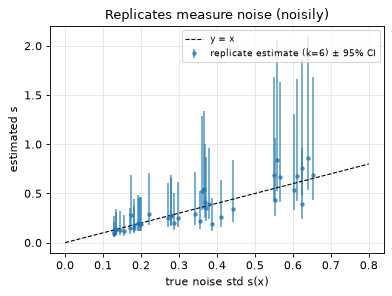

In [3]:
k, n_designs = 6, 40
rep_idx = perm[2000:2000 + n_designs]
X_rep = X_pool[rep_idx]
reps = np.stack([oracle.measure(X_rep, np.random.default_rng([7, j]))[0] for j in range(k)])  # (k, n)
s_hat = reps.std(axis=0, ddof=1)
lo = s_hat * np.sqrt((k - 1) / stats.chi2.ppf(0.975, k - 1))
hi = s_hat * np.sqrt((k - 1) / stats.chi2.ppf(0.025, k - 1))
inside = np.mean((s_pool[rep_idx] >= lo) & (s_pool[rep_idx] <= hi))
print(f"{n_designs} designs x {k} replicates = {k * n_designs} experiments; "
      f"true s inside its 95% chi-square CI for {inside:.0%} of designs")

fig, ax = plt.subplots(figsize=(5, 3.8))
order = np.argsort(s_pool[rep_idx])
ax.errorbar(s_pool[rep_idx][order], s_hat[order], yerr=[s_hat[order] - lo[order], hi[order] - s_hat[order]],
            fmt="o", ms=3, alpha=0.7, label=f"replicate estimate (k={k}) ± 95% CI")
ax.plot([0, 0.8], [0, 0.8], "k--", lw=1, label="y = x")
ax.set(xlabel="true noise std s(x)", ylabel="estimated s", title="Replicates measure noise (noisily)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 2 · Heteroscedasticity

The oracle's noise grows smoothly along a hidden latent direction ($s \in (0.1, 0.7)$). A model
that reports one global σ (the MSE-trained `Predictor` adds a constant `residual_std`) is
**over-confident in noisy regions and under-confident in quiet ones**, even if its average
coverage looks right. A heteroscedastic model learns $s_\theta(x)$ with a variance head and the
Gaussian NLL loss (`training.loss: gaussian_nll`, `models.losses.gaussian_nll_loss`).

In [4]:
train_frame = measured(perm[3000:4500], round_id=0)
calib_frame = measured(perm[4500:5000], round_id=0)        # held-out rows for post-hoc calibration
homo = fit(train_frame, "homo")
hetero = fit(train_frame, "hetero", **{"training.loss": "gaussian_nll", "training.epochs": 15})
y_test, _ = oracle.measure(X_pool[test_idx], np.random.default_rng(11))
tercile = pd.qcut(s_pool[test_idx], 3, labels=["quiet", "medium", "noisy"])

def calib_scale(model):
    # variance scaling: one factor so that 95% of *held-out* |residual| / sigma fall inside 1.96
    mu, sd = model.predict_with_uncertainty(calib_frame, 20, seed=0, include_aleatoric=True)
    return np.quantile(np.abs(calib_frame.response.to_numpy() - mu) / sd, 0.95) / 1.96

rows = []
for name, model, scale in (("homoscedastic (MSE + constant σ)", homo, 1.0),
                           ("heteroscedastic (Gaussian NLL head)", hetero, 1.0),
                           ("heteroscedastic + variance scaling", hetero, calib_scale(hetero))):
    mu, sd = model.predict_with_uncertainty(TEST, 20, seed=0, include_aleatoric=True)
    sd = sd * scale
    row = {"model": name, "σ scale": scale, "all": coverage(y_test, mu, sd, 1.96)}
    row.update({t: coverage(y_test[tercile == t], mu[tercile == t], sd[tercile == t], 1.96)
                for t in ("quiet", "medium", "noisy")})
    row["Spearman(σ, true s)"] = stats.spearmanr(sd, s_pool[test_idx])[0]
    rows.append(row)
print("95% interval coverage of new measurements, by true-noise tercile:")
pd.DataFrame(rows).set_index("model")

95% interval coverage of new measurements, by true-noise tercile:


,σ scale,all,quiet,medium,noisy,"Spearman(σ, true s)"
model,,,,,,
homoscedastic (MSE + constant σ),1.0000,0.9555,0.9880,0.9715,0.9070,0.1924
heteroscedastic (Gaussian NLL head),1.0000,0.8235,0.8531,0.8318,0.7856,0.5763
heteroscedastic + variance scaling,1.6706,0.9660,0.9805,0.9670,0.9505,0.5763


* The homoscedastic model's *average* coverage is fine, but it over-covers quiet regions and
  under-covers noisy ones — its σ does not track $s(x)$ at all.
* The NLL head learns the **shape** of the noise (rank correlation with the true $s$), but its
  raw σ is too small: it is fitted to *training* residuals, which exclude the model's own
  generalisation error, and MC-dropout epistemic spread is too small to fill the gap.
* A one-parameter post-hoc recalibration on held-out rows fixes the scale and keeps the shape:
  coverage is closer to 95 % in every tercile. Calibrate on data the model never trained on.

## 3 · Aleatoric vs epistemic uncertainty, and the small-N learning curve

Epistemic uncertainty should shrink as data grows; aleatoric noise $s(x)$ is a property of the
experiment and does not. Active learning should chase *epistemic* uncertainty — re-measuring a
design because its measurements are noisy teaches the model little. (That is why `select_batch`
ranks with `predict_pool`'s epistemic `pred_std`.)

We train on $n \in \{50, \dots, 1600\}$ experiments and compare two epistemic estimates: the
repository's **MC dropout** (one model, 20 stochastic passes) and a **4-member deep ensemble**
(same architecture, different seeds) as a reference.

In [5]:
curve = []
for n in (50, 100, 200, 400, 800, 1600):
    frame = measured(perm[3000:3000 + n], round_id=0)
    epochs = int(min(300, max(30, 24_000 // n)))            # keep the number of SGD steps comparable
    members = [fit(frame, f"n{n}_s{sd}", seed=sd, **{"training.epochs": epochs}) for sd in range(4)]
    mu, sd_mc = members[0].predict_with_uncertainty(TEST, 20, seed=0)
    ens = np.stack([m.predict(TEST) for m in members])
    pt, lo, hi = bootstrap_ci(rmse, y_test, ens.mean(0), n=300, seed=0)
    curve.append({"n_train": n, "rmse_vs_measured": pt, "ci_lo": lo, "ci_hi": hi,
                  "rmse_vs_true_f": rmse(f_pool[test_idx], ens.mean(0)),
                  "epistemic: MC dropout": sd_mc.mean(), "epistemic: ensemble": ens.std(0, ddof=1).mean(),
                  "aleatoric (true s)": s_pool[test_idx].mean()})
curve = pd.DataFrame(curve)
curve

,n_train,rmse_vs_measured,ci_lo,ci_hi,rmse_vs_true_f,epistemic: MC dropout,epistemic: ensemble,aleatoric (true s)
0,50,1.1434,1.1041,1.1844,1.0822,0.1228,0.5295,0.3173
1,100,0.8480,0.8174,0.8791,0.7614,0.1237,0.3748,0.3173
2,200,0.7533,0.7255,0.7852,0.6624,0.1309,0.3440,0.3173
3,400,0.6433,0.6223,0.6651,0.5325,0.1539,0.3587,0.3173
4,800,0.5569,0.5358,0.5806,0.4276,0.1634,0.2860,0.3173
5,1600,0.4972,0.4793,0.5185,0.3448,0.1503,0.2564,0.3173


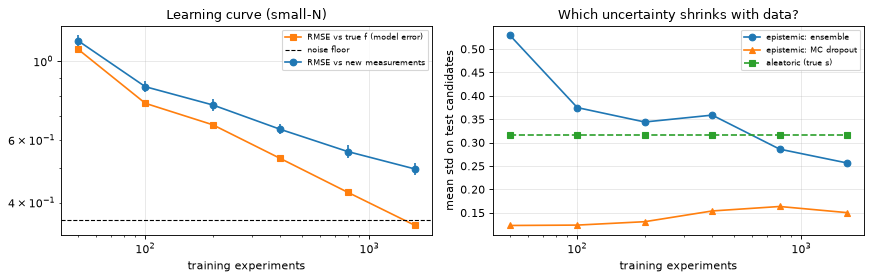

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
ax.errorbar(curve.n_train, curve.rmse_vs_measured, yerr=[curve.rmse_vs_measured - curve.ci_lo,
            curve.ci_hi - curve.rmse_vs_measured], fmt="o-", label="RMSE vs new measurements")
ax.plot(curve.n_train, curve.rmse_vs_true_f, "s-", label="RMSE vs true f (model error)")
ax.axhline(noise_floor, color="k", ls="--", lw=1, label="noise floor")
ax.set(xscale="log", yscale="log", xlabel="training experiments", title="Learning curve (small-N)")
ax.legend(fontsize=7)
ax = axes[1]
for col, st in (("epistemic: ensemble", "o-"), ("epistemic: MC dropout", "^-"), ("aleatoric (true s)", "s--")):
    ax.plot(curve.n_train, curve[col], st, label=col)
ax.set(xscale="log", xlabel="training experiments", ylabel="mean std on test candidates",
       title="Which uncertainty shrinks with data?")
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

* The ensemble spread falls steadily with $n$ — the textbook behaviour of epistemic uncertainty.
  The true aleatoric noise is, of course, flat.
* **MC dropout does not shrink**: with a fixed dropout rate its spread is governed mostly by
  $p$ and the architecture, not by the amount of data. It is still useful for *ranking*
  candidates within one model (what acquisition needs), but its absolute value is not a
  calibrated "how much would more data help" signal. Ensembles, or learning the dropout rate,
  behave better at k× the training cost — a trade-off the platform leaves open on purpose
  (`models/uncertainty.py` says so explicitly).

**Small-N reading.** Model error (squares) falls roughly as a power law in $n$, but the error
against *measurements* (circles) flattens toward the noise floor: beyond some $n$, doubling the
experiments barely moves the metric everyone looks at. Each point also has a wide bootstrap
interval — in the small-N regime, differences between model variants of a few percent are
usually not resolvable (use paired comparisons, notebook 07).

## 4 · Missing data: failed experiments

Experiments fail. The schema models this explicitly (`ExperimentRecord.status == "failed"`,
`response=None`), and `RoundStore.training_frame()` keeps only `measured` rows. Whether that is
harmless depends on **why** data is missing:

* **MCAR** (missing completely at random — a pipetting robot jams at random): the observed rows
  are still a random sample; we just have fewer.
* **MNAR** (missing *not* at random — the assay saturates or cells die exactly when the response
  is extreme): the observed rows under-represent the region we care most about.

In [7]:
base_idx = perm[3000:4200]
records = measure_candidates(pool.iloc[np.sort(base_idx)], oracle, round_id=0, seed=0)
y_all = np.array([r.response for r in records])
q = np.quantile(y_all, 0.75)
p_mnar = 1 / (1 + np.exp(-(y_all - q) * 3))                   # failures concentrate at high responses
p_mcar = np.full_like(p_mnar, p_mnar.mean())                    # same failure *rate*, uniform
rng = np.random.default_rng(3)

def with_failures(p):
    fail = rng.random(len(records)) < p
    return [r.model_copy(update={"status": "failed", "response": None, "measurement_std": None})
            if f else r for r, f in zip(records, fail)]

top = f_pool[test_idx] > np.quantile(f_pool[test_idx], 0.9)     # the region an optimiser cares about
rows = []
for name, p in (("no failures", np.zeros_like(p_mnar)), ("MCAR failures", p_mcar), ("MNAR failures", p_mnar)):
    store = RoundStore(WORK / f"store_{name.split()[0]}")
    store.write_round(0, with_failures(p), provenance={"failure_model": name})
    frame = store.training_frame()                               # measured rows only
    model = fit(frame, f"miss_{name.split()[0]}")
    pred = model.predict(TEST)
    rows.append({"scenario": name, "n_failed": 1200 - len(frame), "n_used": len(frame),
                 "rmse_vs_f (all)": rmse(f_pool[test_idx], pred),
                 "bias in top-10% region": np.mean(pred[top] - f_pool[test_idx][top])})
pd.DataFrame(rows).set_index("scenario")

,n_failed,n_used,rmse_vs_f (all),bias in top-10% region
scenario,,,,
no failures,0,1200,0.4510,-0.0655
MCAR failures,352,848,0.5211,-0.1383
MNAR failures,318,882,0.6186,-1.1010


With the same number of failures, MCAR costs a little accuracy; MNAR makes the model
**systematically under-predict the best designs** — the ones active learning would select.
Record failures (never silently drop them), record *why* they failed, and treat "failed" as
information (e.g. model the failure probability, or impute a censored value).

## 5 · Batch effects: random splits leak experimental conditions

In a real lab each round is measured together and shares a hidden offset $b_r$. If rounds also
explore **different regions** of design space (they do — active learning moves the frontier),
then "which round was this?" is predictable from $x$, and a flexible model can learn $b_r$ as
if it were part of $f$.

A **random** train/validation split puts rows from the same round on both sides, so the model
is rewarded for memorising $b_r$ — but the next round will have a new, unknown $b_{r+1}$. A
**grouped** split (leave-one-round-out; the pipeline's `train_val_split(strategy="newest_round")`)
asks the question we actually care about: *how well do we predict a new batch?*

Simulation: 6 rounds × 150 experiments, each round concentrated in its own region (top of a
random direction in feature space), with offsets $b_r \sim \mathcal N(0, 0.8^2)$ — or $b_r = 0$
as a control.

In [8]:
be_rng = np.random.default_rng(21)
n_rounds, per_round = 6, 150
avail = perm[5000:]
frames = []
offsets = be_rng.normal(0, 0.8, n_rounds)
used = np.zeros(len(pool), bool); used[perm[:5000]] = True
for r in range(n_rounds):
    u = be_rng.standard_normal(len(FCOLS)); u /= np.linalg.norm(u)
    proj = np.where(used, -np.inf, X_pool @ u)
    idx = np.argsort(-proj)[:per_round * 3]
    idx = be_rng.choice(idx, per_round, replace=False)        # a region, not just its extreme edge
    used[idx] = True
    frames.append(measured(idx, round_id=r))
rounds = pd.concat(frames, ignore_index=True)
print(f"{len(rounds)} rows in {n_rounds} rounds; batch offsets b_r = {np.round(offsets, 2)}")

def cv_rmse(frame, grouped):
    # 6-fold CV: folds = rounds (grouped) or random rows (ungrouped); returns pooled RMSE
    fold = frame.round_id.to_numpy() if grouped else np.random.default_rng(0).permutation(len(frame)) % n_rounds
    errs = []
    for k in range(n_rounds):
        tr, te = frame[fold != k], frame[fold == k]
        m = fit(tr, f"cv_{grouped}_{k}_{time.perf_counter_ns()}")
        errs.append(te.response.to_numpy() - m.predict(te))
    return float(np.sqrt(np.mean(np.concatenate(errs) ** 2)))

rows = []
for label, off in (("with batch effects", offsets), ("control: no batch effects", np.zeros(n_rounds))):
    frame = rounds.copy()
    frame["response"] = frame.response + off[frame.round_id.to_numpy()]
    rows.append({"data": label, "random-split CV RMSE": cv_rmse(frame, grouped=False),
                 "leave-one-round-out CV RMSE": cv_rmse(frame, grouped=True)})
be = pd.DataFrame(rows).set_index("data")
be["optimism of random split"] = be["leave-one-round-out CV RMSE"] - be["random-split CV RMSE"]
be

900 rows in 6 rounds; batch offsets b_r = [ 0.29  1.21 -1.43  1.35 -0.04 -0.64]


,random-split CV RMSE,leave-one-round-out CV RMSE,optimism of random split
data,,,
with batch effects,0.9635,1.4447,0.4812
control: no batch effects,0.7272,0.7049,-0.0223


Without batch effects, the two estimates differ modestly (grouping also extrapolates to a new
region, which is harder). With batch effects, the random split is **markedly optimistic** — it
reports how well the model memorised this campaign's conditions, not how it will do on the next
round. The repository's validation options (`data/datasets.py`):

In [9]:
frame = rounds.copy()
for strategy in ("hash", "random", "newest_round"):
    tr, va = train_val_split(frame, 0.2, seed=0, strategy=strategy)
    shared = sorted(set(tr.round_id) & set(va.round_id))
    print(f"{strategy:>12}: val rounds {sorted(int(r) for r in va.round_id.unique())}  "
          f"(rounds on both sides: {len(shared)})")

        hash: val rounds [0, 1, 2, 3, 4, 5]  (rounds on both sides: 6)
      random: val rounds [0, 1, 2, 3, 4, 5]  (rounds on both sides: 6)
newest_round: val rounds [5]  (rounds on both sides: 0)


`hash` is the default because it is stable across rounds (needed for fair incumbent-vs-candidate
comparisons, notebook 07), and the synthetic oracle has no batch effects. With a real lab,
report `newest_round` (prospective) metrics alongside, and put batch/plate/instrument ids into
the provenance of every `ExperimentRecord` so grouped evaluation — and statistical correction
with per-batch controls — is possible later.

## Connection to this repository

| Concept | Where |
|---|---|
| heteroscedastic noise, noise-free mean (diagnostics) | `src/merge_platform/data/synthetic_oracle.py` → `SyntheticOracle.noise_std`, `.mean`, `.measure` |
| reproducible measurement noise per round | `src/merge_platform/data/generation.py` → `measure_candidates` (RNG from `(oracle.seed, round_id, seed)`) |
| failed experiments as data | `src/merge_platform/data/schema.py` → `ExperimentRecord.status`; `data/datasets.py` → `RoundStore.training_frame` (measured only) |
| epistemic uncertainty | `src/merge_platform/models/uncertainty.py` → `mc_dropout_predict` |
| aleatoric term | `inference/predictor.py` → `predict_with_uncertainty(include_aleatoric=True)` (constant `residual_std`), or `training.loss: gaussian_nll` + `models/losses.py` → `gaussian_nll_loss` |
| split strategies and the batch-effect caveat | `src/merge_platform/data/datasets.py` → `train_val_split` (`hash` / `random` / `newest_round`) |

## Failure modes

* **Ignoring the noise floor** — chasing RMSE improvements that are below the measurement noise.
* **One σ for all** — homoscedastic intervals are wrong in both directions (§2).
* **Exploring noise** — acquiring where *aleatoric* uncertainty is high buys no information.
* **Silently dropped failures** — MNAR missingness biases exactly the high-value region (§4).
* **Row-level splits with batch effects** — optimistic metrics, and models that learn the lab's
  calendar instead of the science (§5).
* **Over-fitting in the small-N regime** — more parameters than experiments; validate with
  grouped, prospective splits and paired comparisons.

## Exercise

1. In §1, how many replicates $k$ are needed so that the 95 % CI for $s$ is within ±20 %?
   Derive it from the $\chi^2$ interval, then check by simulation.
2. In §5, add per-round *control* experiments: the same 5 reference designs measured in every
   round. Estimate $\hat b_r$ from them, subtract, and re-run both CV schemes. How much of the
   gap disappears?
3. Repeat §4 with the heteroscedastic model and a censoring-aware treatment: replace failed
   responses by the saturation value `q` instead of dropping them. Does the top-region bias
   shrink?

In [10]:
import shutil
shutil.rmtree(WORK, ignore_errors=True)
print(f"done in {time.perf_counter() - T0:.1f}s; workspace removed (no Ray used in this notebook)")

done in 22.1s; workspace removed (no Ray used in this notebook)
